In [1]:
from Training_Dataset.data_loader_trainset import DataLoader
import pandas as pd
import pywt
import numpy as np
from scipy.stats import skew, kurtosis, entropy
import os
import matplotlib.pyplot as plt
import threading
import sys 
from Training_Dataset.data_loader_trainset import DataLoader as train_dataloader
from Evaluation_Dataset.data_loader_evalset import DataLoader as eval_dataloader
from scipy.stats import linregress

In [2]:
loader = train_dataloader("Training_Dataset/Controller_Data", "Training_Dataset/Sensor_Data")

controller_df = loader.get_controller_data(1, 1)
if not controller_df.empty:
    print("Controller data shape:", controller_df.shape)
    # print(controller_df.head())

sensor_df = loader.get_sensor_data(1, 1)
if not sensor_df.empty:
    print("Sensor data shape:", sensor_df.shape)
    # print(sensor_df.head())

Controller data shape: (21, 23)
Sensor data shape: (1401359, 6)


In [3]:
sensor_df.columns

Index(['Sample', 'Date/Time', 'Acceleration X (g)', 'Acceleration Y (g)',
       'Acceleration Z (g)', 'AE (V)'],
      dtype='str')

In [4]:
sensor_df.head()

,Sample,Date/Time,Acceleration X (g),Acceleration Y (g),Acceleration Z (g),AE (V)
95272,95272,2025-07-01 10:12:18.721562,0.015481,0.025540,0.018594,0.006627
95273,95273,2025-07-01 10:12:18.721601,0.017224,0.028660,0.014706,0.006744
95274,95274,2025-07-01 10:12:18.721640,0.023165,0.033795,0.028702,0.006587
95275,95275,2025-07-01 10:12:18.721679,0.012511,0.023785,0.018399,0.006632
95276,95276,2025-07-01 10:12:18.721718,0.018128,0.027425,0.015289,0.006676


In [5]:
sensor_df.tail()

,Sample,Date/Time,Acceleration X (g),Acceleration Y (g),Acceleration Z (g),AE (V)
1496626,1496626,2025-07-01 10:13:13.461953,-0.360329,-0.886367,1.171794,0.108288
1496627,1496627,2025-07-01 10:13:13.461992,-0.353097,0.341404,-0.391120,0.107867
1496628,1496628,2025-07-01 10:13:13.462031,-0.859601,1.341589,-1.401961,0.107763
1496629,1496629,2025-07-01 10:13:13.462070,-0.956072,2.172043,-2.885822,0.107674
1496630,1496630,2025-07-01 10:13:13.462109,-0.920493,2.986505,-4.233609,0.107446


In [6]:
sensor_df.shape

(1401359, 6)

# Acceleration Plots 

- X acceleration plots

/var/folders/jk/zhgdpm317x948db3mvv_7lbr0000gn/T/ipykernel_54334/1423996943.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


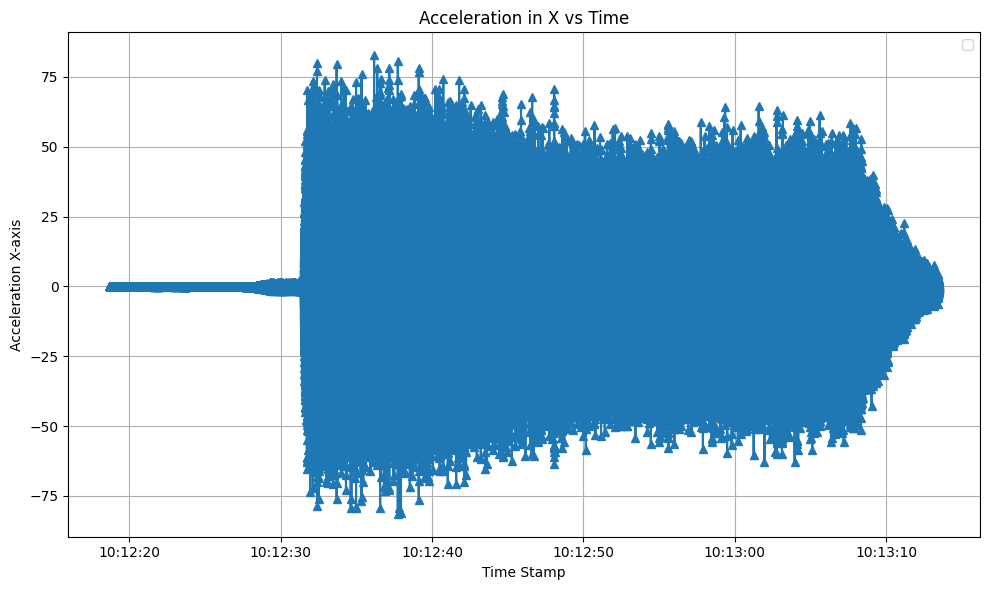

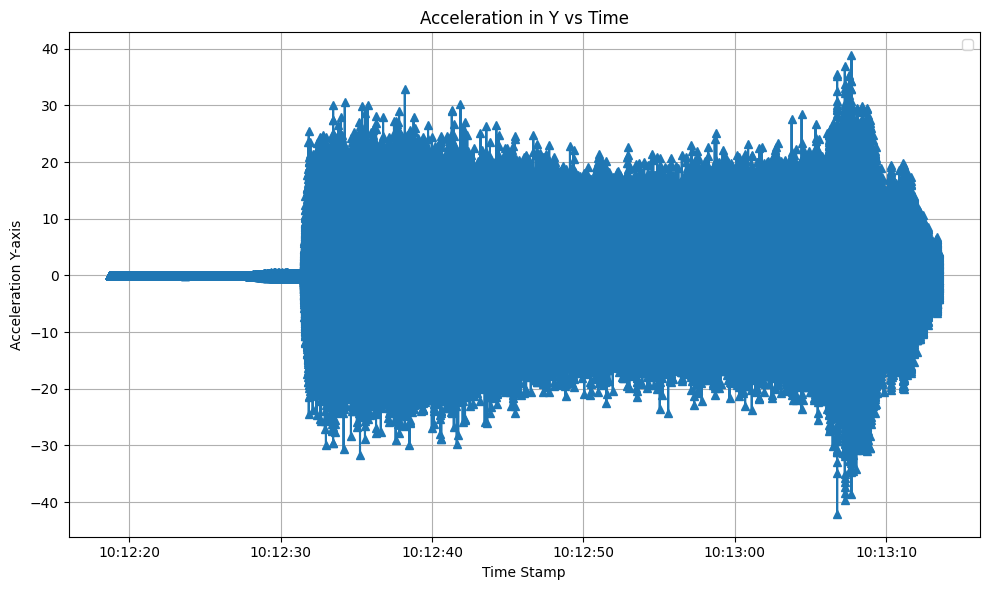

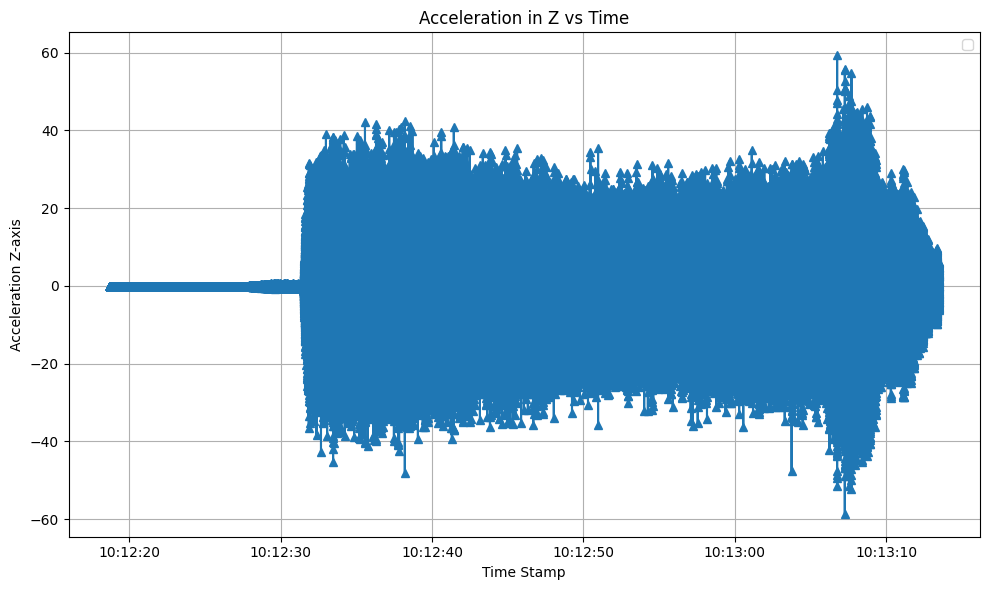

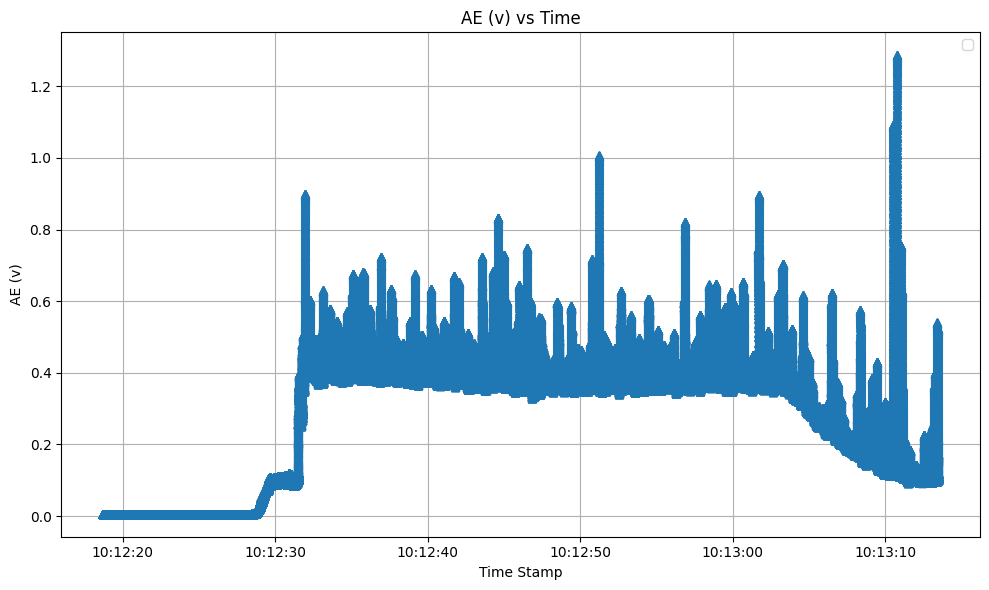

In [7]:


def plot_line_graph(df, feat_2, y_label, title, x_label = 'Time Stamp',  feat_1 = 'Date/Time'):
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # for set_name, group in .groupby("Set_No"):
    ax.plot(df[feat_1], df[feat_2], marker='^')

    ax.set_title(title)
    ax.set_xlabel("Time Stamp")
    ax.set_ylabel(y_label)
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

plot_line_graph(df = sensor_df, feat_2 = 'Acceleration X (g)', y_label = 'Acceleration X-axis', title = 'Acceleration in X vs Time' )
plot_line_graph(df = sensor_df, feat_2 = 'Acceleration Y (g)', y_label = 'Acceleration Y-axis', title = 'Acceleration in Y vs Time' )
plot_line_graph(df = sensor_df, feat_2 = 'Acceleration Z (g)', y_label = 'Acceleration Z-axis', title = 'Acceleration in Z vs Time' )
plot_line_graph(df = sensor_df, feat_2 = 'AE (V)', y_label = 'AE (v)', title = 'AE (v) vs Time' ) # Enhance the AE 


# Analyse Controller numerical features over Time

# Band Frequencies for the Sensor Accelerometer and AE(v) sensor



In [8]:
sensor_df['Date/Time'].diff().dt.total_seconds()


95272           NaN
95273      0.000039
95274      0.000039
95275      0.000039
95276      0.000039
             ...   
1496626    0.000039
1496627    0.000039
1496628    0.000039
1496629    0.000039
1496630    0.000039
Name: Date/Time, Length: 1401359, dtype: float64

# Sampling rate : Sensor Data

In [9]:
dt = sensor_df['Date/Time'].diff().dt.total_seconds().median()
fs = 1 / dt
print(f"Sampling rate: {fs:.0f} Hz")


Sampling rate: 25641 Hz


In [10]:
LEVEL = 8

def compute_band_frequencies(fs, level):
    """
    Compute the frequency range for each wavelet band.
    Band 0 = cA8 (lowest), Band 8 = cD1 (highest).
    """
    bands = {}
    for i in range(level + 1):
        if i == 0:
            # cA8 — approximation coefficients (lowest band)
            f_low  = 0
            f_high = fs / (2 ** (level + 1))
        else:
            # cD bands — detail coefficients
            f_low  = fs / (2 ** (level - i + 2))
            f_high = fs / (2 ** (level - i + 1))
        bands[f'band_{i}'] = (round(f_low, 2), round(f_high, 2))
    return bands

band_freqs = compute_band_frequencies(fs, LEVEL)

print(f"\n{'Band':<10} {'Low (Hz)':<15} {'High (Hz)':<15}")
print("-" * 50)
FREQ_LIMIT = 2 * fs #Nyquist Law :2 * Max_Frequency  # Hz — only keep bands below this
KEEP_BANDS = []
for band, (f_low, f_high) in band_freqs.items():
    keep = f_high <= FREQ_LIMIT
    if keep:
        KEEP_BANDS.append(band)
    print(f"{band:<10} {f_low:<15} {f_high:<15}")

print(f"\nBands to use: {KEEP_BANDS}")



Band       Low (Hz)        High (Hz)      
--------------------------------------------------
band_0     0               50.08          
band_1     50.08           100.16         
band_2     100.16          200.32         
band_3     200.32          400.64         
band_4     400.64          801.28         
band_5     801.28          1602.56        
band_6     1602.56         3205.13        
band_7     3205.13         6410.26        
band_8     6410.26         12820.51       

Bands to use: ['band_0', 'band_1', 'band_2', 'band_3', 'band_4', 'band_5', 'band_6', 'band_7', 'band_8']


# Sampling rate : Controller Features 

In [11]:
dt = sensor_df['Date/Time'].diff().dt.total_seconds().median()
fs = 1 / dt
print(f"Sampling rate: {fs:.0f} Hz")


Sampling rate: 25641 Hz


# Use only wanted bands??

In [12]:
trainset_toolwear_measurement = pd.read_csv(os.path.join('Training_Dataset', 'trainset_toolwear_measurement.csv'))

In [13]:
trainset_toolwear_measurement.head()

,Set_No,Cut_No,Measurement
0,trainset_01,1,31
1,trainset_01,6,67
2,trainset_01,11,92
3,trainset_01,16,101
4,trainset_01,21,152


# Statistical Analysis of Wear 

In [14]:
toolwear_grouped_df = trainset_toolwear_measurement.groupby(by = 'Set_No')


In [15]:
training_sets = trainset_toolwear_measurement['Set_No'].unique()
training_sets

<StringArray>
['trainset_01', 'trainset_02', 'trainset_03', 'trainset_04', 'trainset_05',
 'trainset_06']
Length: 6, dtype: str

In [16]:
measurement_distributions = []


for set in training_sets:
    temp = toolwear_grouped_df.get_group(set)
    measurement_distributions.append(temp['Measurement'].values)

    

# Pairwise Tukey Method

- To analyse the distribution of each trainset, utilise pair wise tukey method to find if they are statistically similar or different

- This ensures us to randomly to choose the training and evaluation dataset during our training so we don't have any skew in the training and the evaluation dataset



In [17]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=trainset_toolwear_measurement['Measurement'],  # values
    groups=trainset_toolwear_measurement['Set_No'],      # group labels
    alpha=0.05
)
print(tukey)


      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj    lower    upper  reject
----------------------------------------------------------------
trainset_01 trainset_02     -6.5 0.9999  -92.1855 79.1855  False
trainset_01 trainset_03  -4.6667    1.0  -90.3521 81.0188  False
trainset_01 trainset_04      4.5    1.0  -81.1855 90.1855  False
trainset_01 trainset_05  -6.1667 0.9999  -91.8521 79.5188  False
trainset_01 trainset_06    -10.5  0.999  -96.1855 75.1855  False
trainset_02 trainset_03   1.8333    1.0  -83.8521 87.5188  False
trainset_02 trainset_04     11.0 0.9987  -74.6855 96.6855  False
trainset_02 trainset_05   0.3333    1.0  -85.3521 86.0188  False
trainset_02 trainset_06     -4.0    1.0  -89.6855 81.6855  False
trainset_03 trainset_04   9.1667 0.9995  -76.5188 94.8521  False
trainset_03 trainset_05     -1.5    1.0  -87.1855 84.1855  False
trainset_03 trainset_06  -5.8333 0.9999  -91.5188 79.8521  False
trainset_04 trainset_05 -

From the above Comparision of Means - Tukey, all the wear distributions are of similar distribution 

In [18]:
df_list = []
for cut in range(1,27):
    controller_df = loader.get_controller_data(1, cut)
    df_list.append(controller_df)

In [19]:
controller_df_combined = pd.concat(df_list, ignore_index=True)
controller_df_combined.head()

,timestamp,progName,progStatus,feedrate,mainSpndLoad,mainSpndSpd,mainSpndStatus,toolSpndLoad,toolSpndSpd,toolSpndStatus,...,A_load,B_load,coolStatus,operMode,cut_no,start_cut,end_cut,step_no,start_step,end_step
0,2025-07-01 10:12:18.721,AMIR-AIMFG,ACTIVE,1500,0,302,ON,0.0,0,0,...,0.0,2,ON,MEM,1,2025-07-01 10:12:18.721555,2025-07-01 10:13:13.462141,1,2025-07-01 10:12:18.721555,2025-07-01 10:12:21.247519
1,2025-07-01 10:12:21.371,AMIR-AIMFG,ACTIVE,1500,0,302,ON,0.0,0,0,...,0.0,2,ON,MEM,1,2025-07-01 10:12:18.721555,2025-07-01 10:13:13.462141,2,2025-07-01 10:12:21.371074,2025-07-01 10:12:23.901910
2,2025-07-01 10:12:24.033,AMIR-AIMFG,ACTIVE,60,0,305,ON,0.0,0,0,...,0.0,2,ON,MEM,1,2025-07-01 10:12:18.721555,2025-07-01 10:13:13.462141,3,2025-07-01 10:12:24.033417,2025-07-01 10:12:26.432930
3,2025-07-01 10:12:26.571,AMIR-AIMFG,ACTIVE,62,0,316,ON,0.0,0,0,...,0.0,2,ON,MEM,1,2025-07-01 10:12:18.721555,2025-07-01 10:13:13.462141,4,2025-07-01 10:12:26.571667,2025-07-01 10:12:29.063659
4,2025-07-01 10:12:29.211,AMIR-AIMFG,ACTIVE,64,3,327,ON,0.0,0,0,...,0.0,1,ON,MEM,1,2025-07-01 10:12:18.721555,2025-07-01 10:13:13.462141,5,2025-07-01 10:12:29.211928,2025-07-01 10:12:31.612420


In [20]:
controller_df_combined.describe(include = 'all')

,timestamp,progName,progStatus,feedrate,mainSpndLoad,mainSpndSpd,mainSpndStatus,toolSpndLoad,toolSpndSpd,toolSpndStatus,...,A_load,B_load,coolStatus,operMode,cut_no,start_cut,end_cut,step_no,start_step,end_step
count,526,526,526,526.000000,526.000000,526.000000,526,526.0,526.0,526.0,...,526.0,526.000000,526,526,526.000000,526,526,526.000000,526,526
unique,NaN,1,1,NaN,NaN,NaN,1,NaN,NaN,NaN,...,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,AMIR-AIMFG,ACTIVE,NaN,NaN,NaN,ON,NaN,NaN,NaN,...,NaN,NaN,ON,MEM,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,526,526,NaN,NaN,NaN,526,NaN,NaN,NaN,...,NaN,NaN,526,526,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-07-01 10:55:31.689325,NaN,NaN,228.180608,2.079848,517.188213,NaN,0.0,0.0,0.0,...,0.0,1.878327,NaN,NaN,13.368821,2025-07-01 10:55:06.511051,2025-07-01 10:56:00.239638,10.676806,2025-07-01 10:55:31.689851,2025-07-01 10:55:34.162942
min,2025-07-01 10:12:18.721000,NaN,NaN,60.000000,0.000000,302.000000,NaN,0.0,0.0,0.0,...,0.0,1.000000,NaN,NaN,1.000000,2025-07-01 10:12:18.721555,2025-07-01 10:13:13.462141,1.000000,2025-07-01 10:12:18.721555,2025-07-01 10:12:21.247519
25%,2025-07-01 10:43:09.169500,NaN,NaN,73.000000,1.000000,343.000000,NaN,0.0,0.0,0.0,...,0.0,2.000000,NaN,NaN,7.000000,2025-07-01 10:42:52.841511,2025-07-01 10:43:47.521698,6.000000,2025-07-01 10:43:09.170232,2025-07-01 10:43:11.653078
50%,2025-07-01 10:57:00.357000,NaN,NaN,90.000000,3.000000,444.000000,NaN,0.0,0.0,0.0,...,0.0,2.000000,NaN,NaN,13.000000,2025-07-01 10:56:17.361069,2025-07-01 10:57:09.393171,11.000000,2025-07-01 10:57:00.357756,2025-07-01 10:57:02.827500
75%,2025-07-01 11:11:46.341250,NaN,NaN,160.000000,3.000000,781.750000,NaN,0.0,0.0,0.0,...,0.0,2.000000,NaN,NaN,20.000000,2025-07-01 11:11:28.806879,2025-07-01 11:12:23.310710,16.000000,2025-07-01 11:11:46.341308,2025-07-01 11:11:48.820110
max,2025-07-01 11:25:42.356000,NaN,NaN,1500.000000,5.000000,800.000000,NaN,0.0,0.0,0.0,...,0.0,2.000000,NaN,NaN,26.000000,2025-07-01 11:24:52.973492,2025-07-01 11:25:44.845349,23.000000,2025-07-01 11:25:42.356161,2025-07-01 11:25:44.845349


In [21]:
constant_cols = [col for col in controller_df_combined.columns
                 if controller_df_combined[col].nunique() == 1]

for c in constant_cols:
    print(f"{c} → {controller_df_combined[c].iloc[0]}")


progName → AMIR-AIMFG
progStatus → ACTIVE
mainSpndStatus → ON
toolSpndLoad → 0.0
toolSpndSpd → 0
toolSpndStatus → 0
A_load → 0.0
coolStatus → ON
operMode → MEM


In [22]:
df_list = []
for set_no in range(1,7):
    for cut_no in range(1,27):
        ctrl_df = loader.get_controller_data(set_no, cut_no) 
        df_list.append(ctrl_df) 

merged_df = pd.concat(df_list, axis = 0) 

In [23]:
merged_df.describe()

,timestamp,feedrate,mainSpndLoad,mainSpndSpd,toolSpndLoad,toolSpndSpd,toolSpndStatus,X_load,Y_load,Z_load,A_load,B_load,cut_no,start_cut,end_cut,step_no,start_step,end_step
count,1590,1590.000000,1590.000000,1590.000000,1590.0,1590.0,1590.0,1590.000000,1590.000000,1590.000000,1590.0,1590.000000,1590.000000,1590,1590,1590.000000,1590,1590
mean,2025-07-06 04:08:28.236031,220.508805,2.098113,520.437107,0.0,0.0,0.0,-17.744025,-27.311321,0.495597,0.0,1.325157,13.420755,2025-07-06 04:08:02.818532,2025-07-06 04:08:56.545724,10.754088,2025-07-06 04:08:28.236551,2025-07-06 04:08:30.704955
min,2025-07-01 10:12:18.721000,0.000000,0.000000,302.000000,0.0,0.0,0.0,-55.000000,-48.000000,-35.000000,0.0,0.000000,1.000000,2025-07-01 10:12:18.721555,2025-07-01 10:13:13.462141,1.000000,2025-07-01 10:12:18.721555,2025-07-01 10:12:21.247519
25%,2025-07-01 11:11:55.464000,73.000000,1.000000,343.000000,0.0,0.0,0.0,-17.000000,-29.000000,-4.000000,0.0,1.000000,7.000000,2025-07-01 11:11:28.806879,2025-07-01 11:12:23.310710,6.000000,2025-07-01 11:11:55.464381,2025-07-01 11:11:57.902775
50%,2025-07-07 14:04:40.431500,90.000000,3.000000,447.500000,0.0,0.0,0.0,-16.000000,-26.000000,0.000000,0.0,1.000000,13.000000,2025-07-07 14:04:33.988836,2025-07-07 14:05:25.878217,11.000000,2025-07-07 14:04:40.431957,2025-07-07 14:04:42.934677
75%,2025-07-09 09:54:47.570750,160.000000,3.000000,799.000000,0.0,0.0,0.0,-16.000000,-23.000000,7.000000,0.0,2.000000,20.000000,2025-07-09 09:54:19.652761,2025-07-09 09:55:16.774133,16.000000,2025-07-09 09:54:47.571283,2025-07-09 09:54:50.067159
max,2025-07-09 10:33:14.312000,1500.000000,5.000000,800.000000,0.0,0.0,0.0,-5.000000,-16.000000,31.000000,0.0,2.000000,26.000000,2025-07-09 10:32:22.298117,2025-07-09 10:33:16.723400,23.000000,2025-07-09 10:33:14.312839,2025-07-09 10:33:16.723400
std,NaN,392.946156,1.408125,194.551853,0.0,0.0,0.0,5.625440,6.593325,8.258088,0.0,0.493439,7.496570,NaN,NaN,5.956569,NaN,NaN


Following features have 0 variance in the train_set 

- toolSpndLoad, toolSpndSpd, toolSpndStatus, A_load


Before removing these features, verify if the evaluation set has the same kind of distribution for these features

In [24]:
# from Evaluation_Dataset.data_loader_evalset import DataLoader 
eval_loader = eval_dataloader('Evaluation_Dataset/Controller_Data', "Evaluation_Dataset/Sensor_Data")

In [25]:
df_list = []
for set_no in range(1,4):
    for cut_no in range(1,27):
        df_list.append(eval_loader.get_controller_data(set_no, cut_no))
    
merged_df_eval = pd.concat(df_list, axis = 0)
merged_df_eval.shape



(1611, 23)

In [26]:
merged_df_eval.describe()

,timestamp,feedrate,mainSpndLoad,mainSpndSpd,toolSpndLoad,toolSpndSpd,toolSpndStatus,X_load,Y_load,Z_load,A_load,B_load,cut_no,start_cut,end_cut,step_no,start_step,end_step
count,1611,1611.000000,1611.000000,1611.000000,1611.0,1611.0,1611.0,1611.000000,1611.000000,1611.000000,1611.0,1611.000000,1611.000000,1611,1611,1611.000000,1611,1611
mean,2025-07-18 19:30:27.748544,210.139665,2.073246,506.160770,0.0,0.0,0.0,-17.703911,-27.648665,0.605214,0.0,1.795158,13.643700,2025-07-18 19:30:01.594548,2025-07-18 19:30:56.753912,11.013656,2025-07-18 19:30:27.749035,2025-07-18 19:30:30.219708
min,2025-07-03 13:44:12.376000,0.000000,0.000000,271.000000,0.0,0.0,0.0,-54.000000,-54.000000,-26.000000,0.0,0.000000,1.000000,2025-07-03 13:44:12.376681,2025-07-03 13:45:09.607901,1.000000,2025-07-03 13:44:12.376681,2025-07-03 13:44:14.897305
25%,2025-07-03 14:50:45.282000,70.000000,1.000000,331.000000,0.0,0.0,0.0,-17.000000,-28.000000,-4.000000,0.0,0.000000,7.000000,2025-07-03 14:50:12.751576,2025-07-03 14:51:04.662665,6.000000,2025-07-03 14:50:45.282227,2025-07-03 14:50:47.812261
50%,2025-07-22 14:28:03.814000,87.000000,3.000000,430.000000,0.0,0.0,0.0,-16.000000,-26.000000,0.000000,0.0,2.000000,14.000000,2025-07-22 14:27:45.670731,2025-07-22 14:28:37.478015,11.000000,2025-07-22 14:28:03.814696,2025-07-22 14:28:06.268206
75%,2025-07-29 15:32:20.219500,157.000000,3.000000,758.500000,0.0,0.0,0.0,-16.000000,-24.000000,9.000000,0.0,3.000000,20.000000,2025-07-29 15:31:44.925641,2025-07-29 15:32:42.206528,16.000000,2025-07-29 15:32:20.220080,2025-07-29 15:32:22.655131
max,2025-07-29 16:12:17.261000,1500.000000,5.000000,800.000000,0.0,0.0,0.0,-13.000000,-16.000000,33.000000,0.0,4.000000,26.000000,2025-07-29 16:11:22.569791,2025-07-29 16:12:19.761069,24.000000,2025-07-29 16:12:17.261711,2025-07-29 16:12:19.761069
std,NaN,382.307154,1.376682,197.442136,0.0,0.0,0.0,5.698848,6.332463,8.727586,0.0,1.484998,7.409725,NaN,NaN,6.120006,NaN,NaN


In [27]:
merged_df.describe(include = 'string')

,progName,progStatus,mainSpndStatus,coolStatus,operMode
count,1590,1590,1590,1590,1590
unique,1,1,1,1,1
top,AMIR-AIMFG,ACTIVE,ON,ON,MEM
freq,1590,1590,1590,1590,1590


The same features have 0 variance in the evaluation dataset, hence removing these features for the further modeling and feature extraction part 

In [28]:
variance_zero_cols = ['toolSpndLoad', 'toolSpndSpd', 'toolSpndStatus', 'A_load', 'progName', 'progStatus', 'mainSpndStatus', 'coolStatus', 'operMode']
CTRL_DROP_COLS = ['timestamp']

In [29]:
controller_df.drop(columns = variance_zero_cols, axis = 0, inplace = True) 
controller_df.drop(columns = CTRL_DROP_COLS, axis = 0, inplace = True)

In [30]:
controller_df.columns

Index(['feedrate', 'mainSpndLoad', 'mainSpndSpd', 'X_load', 'Y_load', 'Z_load',
       'B_load', 'cut_no', 'start_cut', 'end_cut', 'step_no', 'start_step',
       'end_step'],
      dtype='str')

# Frequency estimation for the Controller Features 

In [31]:
dt_ctrl = merged_df['timestamp'].diff().dt.total_seconds().median()
print(dt_ctrl) 
fs_ctrl = 1 / dt_ctrl
print(f"Sampling rate for Controller Sensor Readings: {fs_ctrl} Hz")


2.61
Sampling rate for Controller Sensor Readings: 0.3831417624521073 Hz


# Verify TrainSet Controller DF features

In [32]:

# ── Configuration ─────────────────────────────────────────────────────────────
EVAL_SETS     = [1,2,3]
TRAIN_SETS = [1,2,3,4,5,6]
CUT_NOS  = list(range(1, 27))          # all 26 cuts
LABELED  = [1, 6, 11, 16, 21, 26]     # cuts with measured wear

WAVELET  = 'db4'
LEVEL    = 8
N_BANDS  = 6   # keep bands 0–6 (≤ 5000 Hz)

SENSOR_COLS = [
    'Acceleration X (g)',
    'Acceleration Y (g)',
    'Acceleration Z (g)',
    'AE (V)'
]

CONTROLLER_COLS = [
    'feedrate', 'mainSpndLoad', 'mainSpndSpd',
    'X_load', 'Y_load', 'Z_load'
]

eval_loader = eval_dataloader(
    controller_data_path="Evaluation_Dataset/Controller_Data",
    sensor_data_path="Evaluation_Dataset/Sensor_Data",
    set_available=EVAL_SETS
)

train_loader = train_dataloader(controller_data_path="Training_Dataset/Controller_Data",
    sensor_data_path="Training_Dataset/Sensor_Data",
    set_available=TRAIN_SETS
)


wear_df_eval = pd.read_csv("Evaluation_Dataset/evalset_toolwear_measurement.csv")
wear_df_train = pd.read_csv("Training_Dataset/trainset_toolwear_measurement.csv")

# TRAIN WEAR Dataset creation 
wear_df_train['set_no'] = wear_df_train['Set_No'].str.extract(r'(\d+)').astype(int)
wear_df_train = wear_df_train.rename(columns={'Cut_No': 'cut_no', 'Measurement': 'flank_wear_um'})

# EVAL WEAR
wear_df_eval['set_no'] = wear_df_eval['Set_No'].str.extract(r'(\d+)').astype(int)
wear_df_eval = wear_df_eval.rename(columns={'Cut_No': 'cut_no', 'Measurement': 'flank_wear_um'})


# FEATURE ENGINEERING 

In [33]:

def safe_col_name(col):
    """Sanitise column name for use as a dict key."""
    return col.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')

def stat_features(signal, prefix):
    """
    Only for Sensor Dataframe
    Extract 9 statistical features from a 1D array.
    Works for both raw signal and wavelet coefficients.
    """
    signal = np.array(signal, dtype=float)
    total  = np.sum(np.abs(signal)) + 1e-12  # avoid div by zero in entropy

    return {
        f'{prefix}_min':            np.min(signal),
        f'{prefix}_max':            np.max(signal),
        f'{prefix}_mean':           np.mean(signal),
        f'{prefix}_std':            np.std(signal),
        f'{prefix}_skew':           skew(signal),
        f'{prefix}_kurtosis':       kurtosis(signal),
        f'{prefix}_energy':         np.sum(np.square(signal)),
        f'{prefix}_entropy':        entropy(np.abs(signal) / total),
        f'{prefix}_zero_crossings': int(np.sum(np.diff(np.sign(signal)) != 0)),
    }



def sensor_features(signal, col_name):
    """
    Full feature set for one sensor channel:
      - 9 time-domain stats on the raw signal
    Total: 54 features per channel
    """
    signal = np.asarray(signal, dtype = float).copy()
    features = {}

    # Time-domain features on raw signal
    features.update(stat_features(signal, col_name))

    # Wavelet decomposition → keep bands 0–6
    coeffs = pywt.wavedec(signal, WAVELET, level=LEVEL)
    for i, coeff in enumerate(coeffs[:N_BANDS]):
        features.update(stat_features(coeff, f'{col_name}_band{i}'))

    return features


def get_numeric_features_controller(series, col_name):
    """
    Only for Controller DF 
    Statistical + trend features for a continuous signal for the controller.
    """
    s = series.dropna()
    if len(s) < 2:
        return {}
    
    slope, _, r2, _, _ = linregress(range(len(s)), s)
    
    return {
        f'{col_name}_mean':    s.mean(),
        f'{col_name}_std':     s.std(),
        f'{col_name}_rms':     np.sqrt((s**2).mean()),
        f'{col_name}_max':     s.max(),
        f'{col_name}_min':     s.min(),
        f'{col_name}_range':   s.max() - s.min(),
        f'{col_name}_iqr':     s.quantile(0.75) - s.quantile(0.25),
        f'{col_name}_slope':   slope,       # intra-cut trend
        f'{col_name}_trend_r2': r2,
    }








def controller_features(c_df):
    """
    Aggregate controller readings across ~21 timesteps per cut.
    Only time-domain stats (too few rows for wavelet).
    cut_duration_s computed from start_cut/end_cut before metadata is dropped.
    """
    features = {}
    # ── 1. Extract cut duration BEFORE dropping metadata columns ──────────
    cut_duration_s = float('nan')


    
    start = c_df['start_cut'].dropna().iloc[0]
    end   = c_df['end_cut'].dropna().iloc[0]
    cut_duration_s = (end - start).total_seconds()



    # ── 2. Drop ALL metadata + step columns ───────────────────────────────
    drop_cols = [c for c in ['start_cut', 'end_cut', 'start_step', 'end_step'] 
                 if c in c_df.columns]

    c_df = c_df.drop(columns=drop_cols)


    # ── 3. Numeric stats on remaining columns ─────────────────────────────
    numeric_cols = ['feedrate', 'mainSpndLoad', 'mainSpndSpd', 'X_load', 'Y_load', 'Z_load','B_load']
    for col in numeric_cols:
        features.update(get_numeric_features_controller(c_df[col], col))


    # ── 4. Append duration last ───────────────────────────────────────────
    if cut_duration_s == np.nan:
        raise Exception('Nan Value')
    features['cut_duration_s'] = cut_duration_s
    return features


# TRAINSET FEATURE EXTRACTION

In [ ]:

# # Feature extraction 
# records = []
# skipped = []


# for set_no in TRAIN_SETS:
#     for cut_no in CUT_NOS:
#         print(f"  trainset_{set_no:02d} | Cut {cut_no:02d} ...", end=' ')

#         sensor_df = train_loader.get_sensor_data(set_no, cut_no)
#         ctrl_df   = train_loader.get_controller_data(set_no, cut_no)


#         ctrl_df.drop(columns = variance_zero_cols, inplace = True) 
#         ctrl_df.drop(columns = CTRL_DROP_COLS, inplace = True )
#         if sensor_df.empty or ctrl_df.empty:
#             print("⚠ skipped (no data)")
#             skipped.append((set_no, cut_no))
#             continue

#         row = {'set_no': set_no, 'cut_no': cut_no}

#         # ── Sensor features ──────────────────────────────────────────
#         for col in SENSOR_COLS:
#             if col not in sensor_df.columns:
#                 continue
#             signal = sensor_df[col].dropna().to_numpy(dtype=float, copy=True)  # ← safest
#             col_name = safe_col_name(col)
#             row.update(sensor_features(signal, col_name))

#         # ── Controller features ──────────────────────────────────────
#         row.update(controller_features(ctrl_df))
        
#         records.append(row)
#         if len(records) == 1:
#             print(f"\n── Feature columns ({len(row)} total) ──")
#             print(row.keys())
#         print(f"✅  ({len(sensor_df):,} sensor rows)")

# feature_df_train = pd.DataFrame(records)
# print(f"\nFeature matrix shape (all cuts): {feature_df_train.shape}")

# if skipped:
#     print(f"Skipped {len(skipped)} cut(s): {skipped}")



# feature_df_train = feature_df_train.merge(
#     wear_df_train[['set_no', 'cut_no', 'flank_wear_um']],
#     on=['set_no', 'cut_no'],
#     how='left'
# )



  trainset_01 | Cut 01 ... 
── Feature columns (318 total) ──
dict_keys(['set_no', 'cut_no', 'Acceleration_X_g_min', 'Acceleration_X_g_max', 'Acceleration_X_g_mean', 'Acceleration_X_g_std', 'Acceleration_X_g_skew', 'Acceleration_X_g_kurtosis', 'Acceleration_X_g_energy', 'Acceleration_X_g_entropy', 'Acceleration_X_g_zero_crossings', 'Acceleration_X_g_band0_min', 'Acceleration_X_g_band0_max', 'Acceleration_X_g_band0_mean', 'Acceleration_X_g_band0_std', 'Acceleration_X_g_band0_skew', 'Acceleration_X_g_band0_kurtosis', 'Acceleration_X_g_band0_energy', 'Acceleration_X_g_band0_entropy', 'Acceleration_X_g_band0_zero_crossings', 'Acceleration_X_g_band1_min', 'Acceleration_X_g_band1_max', 'Acceleration_X_g_band1_mean', 'Acceleration_X_g_band1_std', 'Acceleration_X_g_band1_skew', 'Acceleration_X_g_band1_kurtosis', 'Acceleration_X_g_band1_energy', 'Acceleration_X_g_band1_entropy', 'Acceleration_X_g_band1_zero_crossings', 'Acceleration_X_g_band2_min', 'Acceleration_X_g_band2_max', 'Acceleration_X_

In [47]:

# Feature extraction 
records = []
skipped = []

for set_no in EVAL_SETS:
    for cut_no in CUT_NOS:
        print(f"  evalset_{set_no:02d} | Cut {cut_no:02d} ...", end=' ')

        sensor_df = eval_loader.get_sensor_data(set_no, cut_no)
        ctrl_df   = eval_loader.get_controller_data(set_no, cut_no)
        


        if sensor_df.empty or ctrl_df.empty:
            print("⚠ skipped (no data)")
            skipped.append((set_no, cut_no))
            continue
        ctrl_df.drop(columns = variance_zero_cols, inplace = True) 
        ctrl_df.drop(columns = CTRL_DROP_COLS, inplace = True )
        row = {'set_no': set_no, 'cut_no': cut_no}

        # ── Sensor features ──────────────────────────────────────────
        for col in SENSOR_COLS:
            if col not in sensor_df.columns:
                continue
            signal = sensor_df[col].dropna().to_numpy(dtype=float, copy=True)  # ← safest
            col_name = safe_col_name(col)
            row.update(sensor_features(signal, col_name))

        # ── Controller features ──────────────────────────────────────
        row.update(controller_features(ctrl_df))

        records.append(row)
        if len(records) == 1:
            print(f"\n── Feature columns ({len(row)} total) ──")
            # for col in row.keys():
            #     print(f"  {col}")
        print(f"✅  ({len(sensor_df):,} sensor rows)")

feature_df_eval = pd.DataFrame(records)
print(f"\nFeature matrix shape (all cuts): {feature_df_eval.shape}")

if skipped:
    print(f"Skipped {len(skipped)} cut(s): {skipped}")

feature_df_eval = feature_df_eval.merge(
    wear_df_train[['set_no', 'cut_no', 'flank_wear_um']],
    on=['set_no', 'cut_no'],
    how='left'
)

  evalset_01 | Cut 01 ... Evaluation_Dataset/Sensor_Data/evalset_01/Part_01_1_1.zip

── Feature columns (318 total) ──
✅  (1,465,119 sensor rows)
  evalset_01 | Cut 02 ... Evaluation_Dataset/Sensor_Data/evalset_01/Part_02_2_6.zip
✅  (1,396,217 sensor rows)
  evalset_01 | Cut 03 ... Evaluation_Dataset/Sensor_Data/evalset_01/Part_02_2_6.zip
✅  (1,396,797 sensor rows)
  evalset_01 | Cut 04 ... Evaluation_Dataset/Sensor_Data/evalset_01/Part_02_2_6.zip
✅  (1,332,802 sensor rows)
  evalset_01 | Cut 05 ... Evaluation_Dataset/Sensor_Data/evalset_01/Part_02_2_6.zip
✅  (1,399,237 sensor rows)
  evalset_01 | Cut 06 ... Evaluation_Dataset/Sensor_Data/evalset_01/Part_02_2_6.zip
✅  (1,327,272 sensor rows)
  evalset_01 | Cut 07 ... Evaluation_Dataset/Sensor_Data/evalset_01/Part_03_7_11.zip
✅  (1,468,069 sensor rows)
  evalset_01 | Cut 08 ... Evaluation_Dataset/Sensor_Data/evalset_01/Part_03_7_11.zip
✅  (1,329,449 sensor rows)
  evalset_01 | Cut 09 ... Evaluation_Dataset/Sensor_Data/evalset_01/Part_03

In [36]:
feature_df_eval.shape, feature_df_train.shape

((156, 320), (156, 319))

In [ ]:
# feature_df_eval.to_csv

,set_no,cut_no,Acceleration_X_g_min,Acceleration_X_g_max,Acceleration_X_g_mean,Acceleration_X_g_std,Acceleration_X_g_skew,Acceleration_X_g_kurtosis,Acceleration_X_g_energy,Acceleration_X_g_entropy,...,B_load_std,B_load_rms,B_load_max,B_load_min,B_load_range,B_load_iqr,B_load_slope,B_load_trend_r2,cut_duration_s,flank_wear_um
0,1,1,-85.405169,95.085860,0.020815,12.929971,0.010835,1.884794,2.449453e+08,13.578670,...,0.509647,1.537412,2,1,1,1.00,0.001129,0.014389,57.231220,31.0
1,1,2,-6.378584,6.905589,0.016755,0.947819,-0.006899,2.235319,1.254699e+06,13.705964,...,0.483046,1.732051,2,1,1,1.00,-0.015584,-0.200185,54.539687,NaN
2,1,3,-126.626363,88.112518,0.012584,13.758212,0.017991,1.663813,2.643977e+08,13.588880,...,0.483046,1.732051,2,1,1,1.00,0.011688,0.150139,54.562393,NaN
3,1,4,-83.755738,85.728901,0.009495,13.739712,0.019278,1.466384,2.516061e+08,13.583464,...,0.410391,1.843909,2,1,1,0.00,-0.010526,-0.151744,52.062554,NaN
4,1,5,-82.071825,85.525305,0.012277,13.370742,0.025545,1.705183,2.501512e+08,13.590074,...,0.497613,1.690309,2,1,1,1.00,-0.009091,-0.113356,54.657691,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,3,22,-82.341414,85.683184,0.169118,11.322779,0.025334,4.761662,8.658073e+07,12.345891,...,0.508977,3.494043,4,3,1,1.00,0.023043,0.320136,62.389234,NaN
73,3,23,-93.208135,92.423421,0.235059,12.956366,-0.007613,1.358532,2.460566e+08,13.683099,...,0.492366,3.397860,4,3,1,1.00,0.019198,0.253196,57.238165,NaN
74,3,24,-76.521718,80.751484,0.030618,12.758069,-0.011465,1.379021,2.386101e+08,13.680204,...,0.394771,3.205110,4,3,1,0.00,0.032750,0.538702,57.263335,NaN
75,3,25,-82.355361,81.553083,-0.012824,12.681273,-0.004428,1.376126,2.352203e+08,13.670864,...,0.428932,3.254368,4,3,1,0.00,0.007340,0.111127,57.135866,NaN


# Save features

In [49]:
feature_df_eval.to_csv('evaluation_features.csv')

In [ ]:
# feature_df_train.to_csv('train_features.csv')

In [ ]:
# feature_df_train.shape, feature_df_eval.shape

((156, 319), (156, 320))